Aula de Analise exploratoria
como pensam
como agem
oque pensam

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/ratings.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
df.tail()

,userId,movieId,rating,timestamp
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352
100835,610,170875,3.0,1493846415


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
df.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [7]:
df.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [8]:
df.shape

(100836, 4)

In [9]:
df.columns = ['UsuarioId','FilmeId','Nota','Momento']

In [10]:
df.head()

,UsuarioId,FilmeId,Nota,Momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [11]:
df[df['Nota'] > 4]

,UsuarioId,FilmeId,Nota,Momento
3,1,47,5.0,964983815
4,1,50,5.0,964982931
6,1,101,5.0,964980868
8,1,151,5.0,964984041
9,1,157,5.0,964984100
...,...,...,...,...
100821,610,160527,4.5,1479544998
100829,610,164179,5.0,1493845631
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047


In [12]:
df.query('Nota > 4')

,UsuarioId,FilmeId,Nota,Momento
3,1,47,5.0,964983815
4,1,50,5.0,964982931
6,1,101,5.0,964980868
8,1,151,5.0,964984041
9,1,157,5.0,964984100
...,...,...,...,...
100821,610,160527,4.5,1479544998
100829,610,164179,5.0,1493845631
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047


quais os valores que contem a coluna Nota

In [13]:
df['Nota'].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

quantas vezes aparece cada valor

In [14]:
df['Nota'].value_counts()

,count
Nota,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


nota que menos aparece é nota meio 0.5

notas mais altas que baixas

In [15]:
df['Nota'].mean()

np.float64(3.501556983616962)

visualização

<Axes: ylabel='Frequency'>

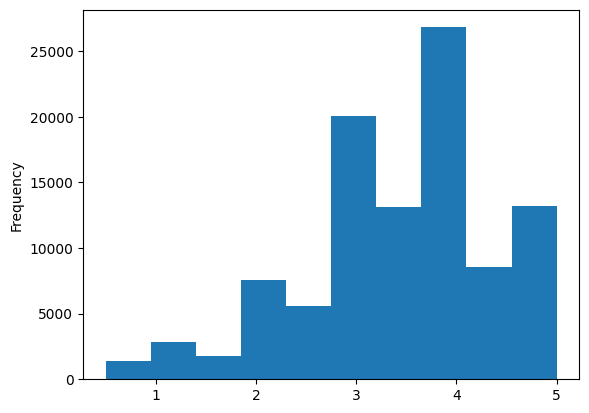

In [16]:
df['Nota'].plot(kind='hist')

In [17]:
media = df['Nota'].mean()
mediana = df['Nota'].median()
print(f'Mediana é {mediana} e a media é {media}')

Mediana é 3.5 e a media é 3.501556983616962


preciso aprender sobre quartis

In [18]:
df['Nota'].describe()

,Nota
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


In [19]:
import seaborn as sns

<Axes: ylabel='Nota'>

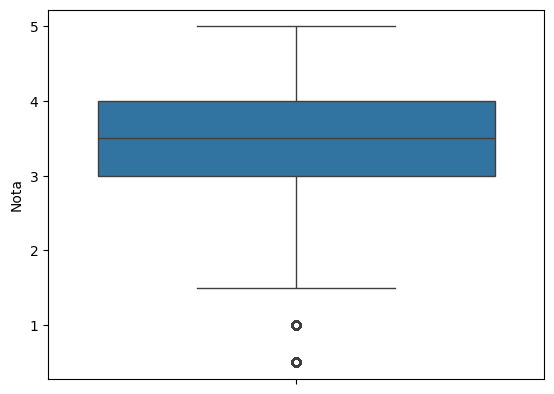

In [20]:
sns.boxplot(df['Nota'])

Complemento para nossas analises

In [21]:
url2 = 'https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/movies.csv'
filmes = pd.read_csv(url2)
filmes.columns = ['FilmeId', 'Titulo', 'Genero']

In [22]:
filmes.head()

,FilmeId,Titulo,Genero
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [23]:
filmes.shape

(9742, 3)

In [24]:
df.head()

,UsuarioId,FilmeId,Nota,Momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [25]:
df.shape

(100836, 4)

In [26]:
media_por_filme = df.groupby('FilmeId')['Nota'].mean()
media_por_filme.head()

,Nota
FilmeId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


<Axes: ylabel='Frequency'>

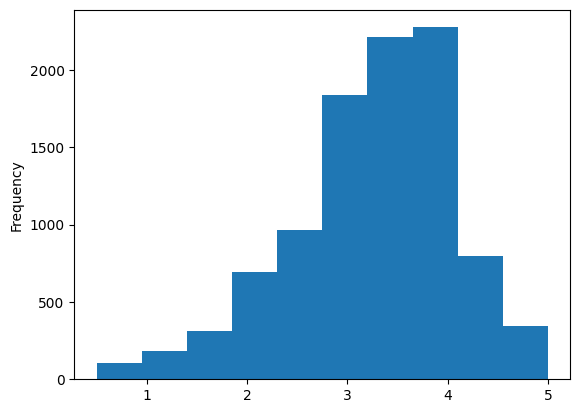

In [27]:
media_por_filme.plot(kind='hist')

In [28]:
df['Nota'].value_counts()

,count
Nota,
4.0,26818
3.0,20047
5.0,13211
3.5,13136
4.5,8551
2.0,7551
2.5,5550
1.0,2811
1.5,1791


a analise mudou, o ultimo histograma mostrava 3.5, mas varios filmes possuem uma media muito proxima de 4, acima de 4 é bem incomum

Organizar nota por filme
dataframe com notas é df
dataframe com filmes é filmes

In [29]:
filmes.head()

,FilmeId,Titulo,Genero
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


MEDIA DE NOTAS POR FILME

In [30]:
media_por_filme = df.groupby('FilmeId')['Nota'].mean()
media_por_filme.head()

,Nota
FilmeId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


<Axes: ylabel='Frequency'>

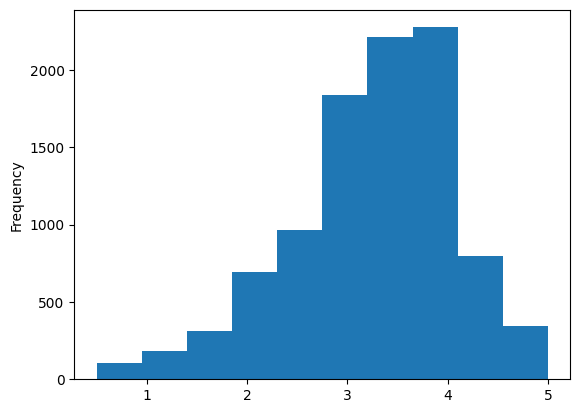

In [31]:
media_por_filme.plot(kind='hist')

In [32]:
import seaborn as sns

<Axes: ylabel='Nota'>

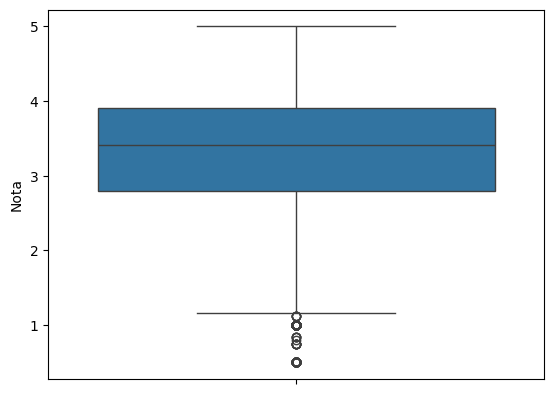

In [33]:
sns.boxplot(media_por_filme)

In [34]:
media_por_filme.describe()

,Nota
count,9724.000000
mean,3.262448
std,0.869874
min,0.500000
25%,2.800000
50%,3.416667
75%,3.911765
max,5.000000


Text(0.5, 1.0, 'histograma media filmes')

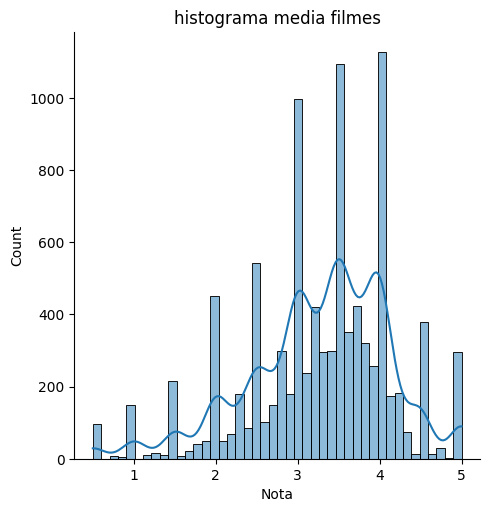

In [39]:
import matplotlib.pyplot as plt
sns.displot(media_por_filme, kde=True)
plt.title("histograma media filmes")
